# Special Extra!!

Getting the best models to generate an SVG

Inspired by the legendary Simon Willison's Pelican riding a bike test

Key point: this is a very different task to image generation! The model needs to describe the image with lines and shapes.

### This uses OpenRouter, Groq, and Ollama for model access

In [7]:
from dotenv import load_dotenv
from IPython.display import Markdown, display
from datetime import datetime
import time
from revealer import reveal
from openai import OpenAI
import os
load_dotenv(override=True)

True

In [8]:
groq_api_key = os.getenv('GROQ_API_KEY')
openrouter_api_key = os.getenv('OPENROUTER_API_KEY')

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq API Key not set")

if openrouter_api_key:
    print(f"OpenRouter API Key exists and begins {openrouter_api_key[:3]}")
else:
    print("OpenRouter API Key not set")

print("Ollama doesn't need an API key - just make sure it's running!")

Groq API Key exists and begins gsk_
OpenRouter API Key exists and begins sk-
Ollama doesn't need an API key - just make sure it's running!


In [9]:
# Set up clients

# Option 1: Groq (fast, free tier)
groq_url = "https://api.groq.com/openai/v1"
groq = OpenAI(api_key=groq_api_key, base_url=groq_url)

# Option 2: OpenRouter (access to many models including GPT, Claude)
openrouter_url = "https://openrouter.ai/api/v1"
openrouter = OpenAI(base_url=openrouter_url, api_key=openrouter_api_key)

# Option 3: Ollama (local, completely free)
ollama_url = "http://localhost:11434/v1"
ollama = OpenAI(api_key="ollama", base_url=ollama_url)

# Using Groq for free tier models
client = groq

In [14]:
challenge = "a panda rollerblading to work"
prompt = f"Generate an SVG of {challenge}. Respond with the SVG only, no code blocks."
messages = [{"role": "user", "content": prompt}]

In [15]:
def artist(model, effort=None):
    try:
        start = datetime.now()
        # Use client variable to easily switch between providers
        response = client.chat.completions.create(model=model, messages=messages, reasoning_effort=effort)
        result = response.choices[0].message.content
        end = datetime.now()
        elapsed = (end - start).total_seconds()
        heading = f"### {model}\n**Time:** {elapsed // 60:.0f} min {elapsed % 60:.0f} s\n\n"
    except Exception as e:
        print(f"Model {model} failed: {e}")
        heading = f"### {model}\n**Error:** {e}\n\n"
        return heading, None
    return heading, result

In [18]:
# Test with FREE models only!
# All models below are completely free to use

# Groq free tier models (currently active, fast and free!)
# Note: Many models have been decommissioned, these are confirmed working
results = [
    artist("llama-3.3-70b-versatile"),
    artist("llama-3.1-8b-instant"),
]

# To also test Ollama local models (completely free), uncomment below:
# client = ollama
# results.extend([
#     artist("llama3.2"),
#     artist("qwen2.5-coder"),
#     artist("deepseek-r1:7b"),
# ])

### llama-3.3-70b-versatile
**Time:** 0 min 2 s



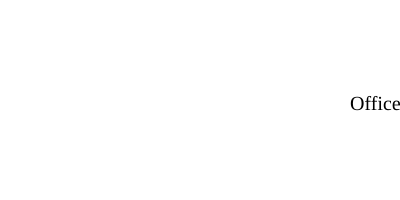

### llama-3.1-8b-instant
**Time:** 0 min 1 s



Error displaying result: not well-formed (invalid token): line 9, column 86


In [20]:
for result in results:
    try:
        display(Markdown(result[0]))
        reveal(result[1])
        time.sleep(12)
    except Exception as e:
        print(f"Error displaying result: {e}")

## In Week 4 we will have more scientific ways to compare models..

but this was quite fun.